In [1]:
import numpy as np
import pandas as pd

In [2]:
col_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_paren', 'char_freq_bracket', 'char_freq_exclaim',
    'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total',
    'spam'
]



## Getting an Overview of the Data

In [5]:
df = pd.read_csv('spambase.data', header = None, names = col_names)
print("First six rows of the dataset:")
df.head(6)

First six rows of the dataset:


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1


In [ ]:
print("Rows and columns in the dataset:")

df.shape

Rows and columns in the dataset:


(4601, 58)

In [ ]:
print("Datatypes of the columns:")
df.dtypes


Datatypes of the columns:


,0
word_freq_make,float64
word_freq_address,float64
word_freq_all,float64
word_freq_3d,float64
word_freq_our,float64
word_freq_over,float64
word_freq_remove,float64
word_freq_internet,float64
word_freq_order,float64
word_freq_mail,float64


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq

In [ ]:
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4601.000000        4601.000000    4601.000000   4601.000000   
mean         0.104553           0.213015       0.280656      0.065425   
std          0.305358           1.290575       0.504143      1.395151   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.000000           0.000000       0.000000      0.000000   
75%          0.000000           0.000000       0.420000      0.000000   
max          4.540000          14.280000       5.100000     42.810000   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count    4601.000000     4601.000000       4601.000000         4601.000000   
mean        0.312223        0.095901          0.114208            0.105295   
std         0.672513        0.273824          0.391441            0.401071   
min       

## Visualizing the Data Before Outlier Removal

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

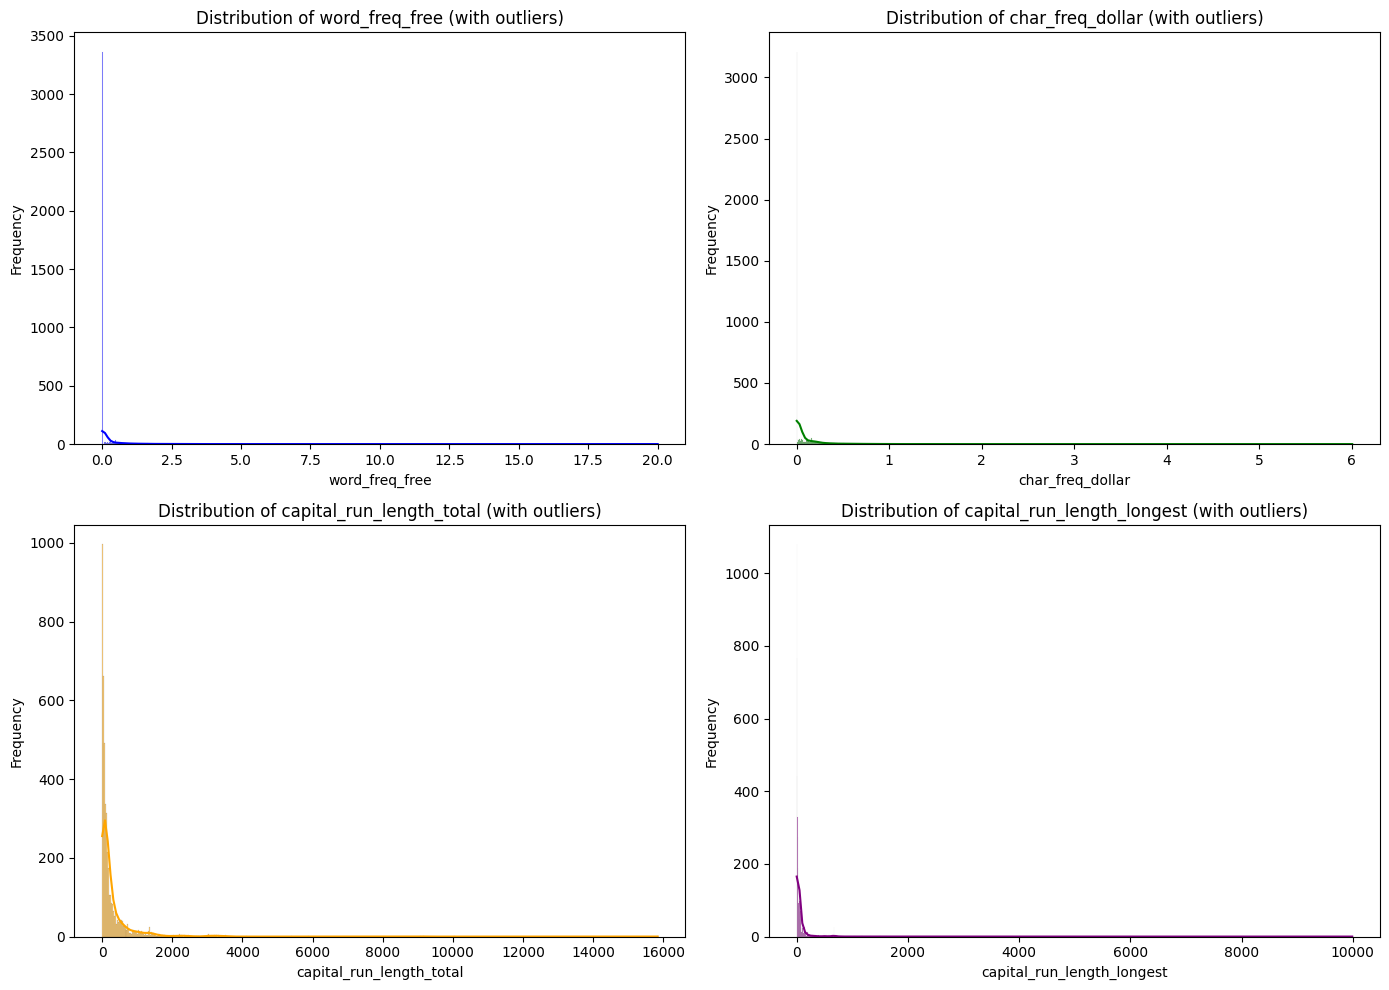

In [7]:

# Plot distribution of key features (before outlier removal)
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['word_freq_free'], kde=True, color='blue')
plt.title('Distribution of word_freq_free (with outliers)')
plt.xlabel('word_freq_free')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(df['char_freq_dollar'], kde=True, color='green')
plt.title('Distribution of char_freq_dollar (with outliers)')
plt.xlabel('char_freq_dollar')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(df['capital_run_length_total'], kde=True, color='orange')
plt.title('Distribution of capital_run_length_total (with outliers)')
plt.xlabel('capital_run_length_total')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(df['capital_run_length_longest'], kde=True, color='purple')
plt.title('Distribution of capital_run_length_longest (with outliers)')
plt.xlabel('capital_run_length_longest')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

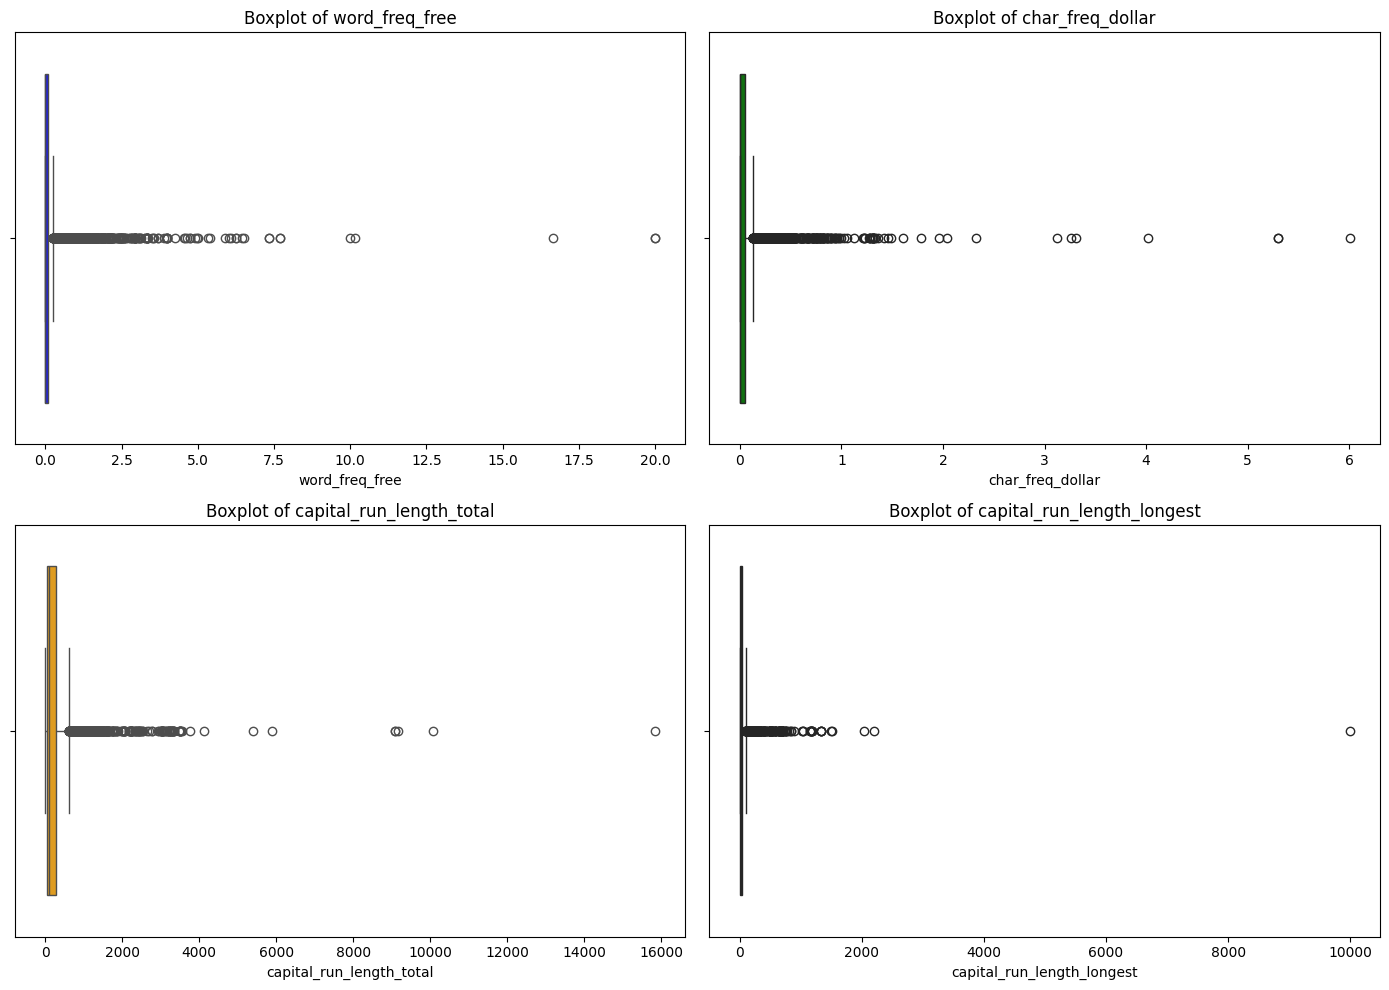

In [8]:
# Boxplots to detect potential outliers (before removal)
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x=df['word_freq_free'], color='blue')
plt.title('Boxplot of word_freq_free')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['char_freq_dollar'], color='green')
plt.title('Boxplot of char_freq_dollar')

plt.subplot(2, 2, 3)
sns.boxplot(x=df['capital_run_length_total'], color='orange')
plt.title('Boxplot of capital_run_length_total')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['capital_run_length_longest'], color='purple')
plt.title('Boxplot of capital_run_length_longest')

plt.tight_layout()
plt.show()

## Detecting and Removing Outliers (Z-Score Method)

In [9]:
feature_cols = df.columns[:-1]   # all columns except the last one ('spam')

In [10]:
from scipy import stats

In [11]:
z_scores = np.abs(stats.zscore(df[feature_cols]))
threshold = 3
df_cleaned = df[(z_scores < threshold).all(axis=1)]

In [12]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Rows removed: {df.shape[0] - df_cleaned.shape[0]}")

Original shape: (4601, 58)
Cleaned shape: (2185, 58)
Rows removed: 2416


## Visualizing the Data After Outlier Removal

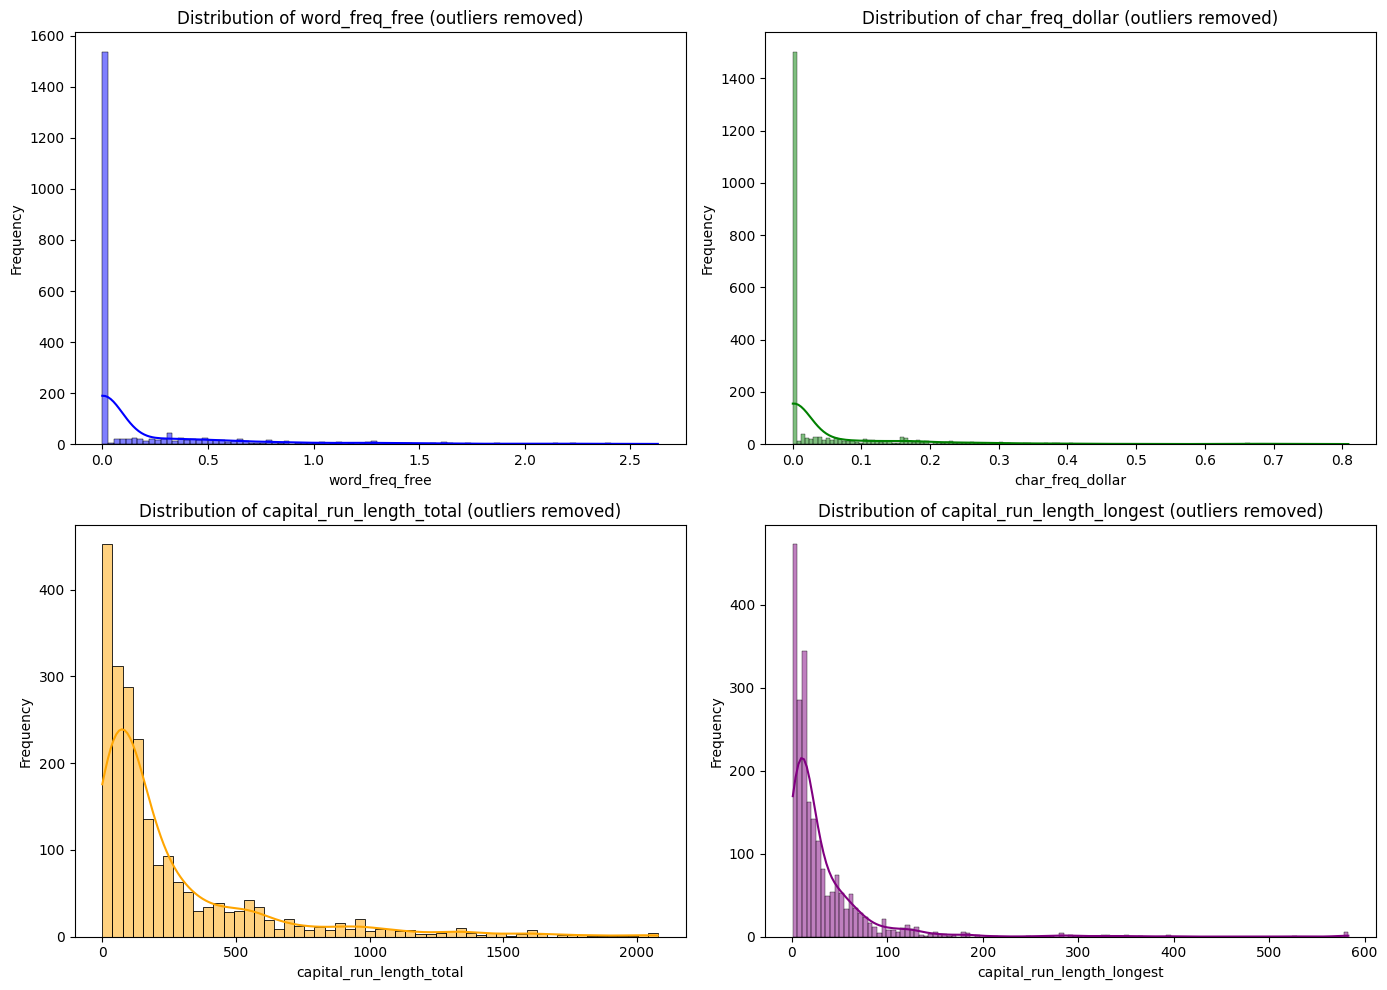

In [13]:
# Plot distribution of key features (after outlier removal)
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_cleaned['word_freq_free'], kde=True, color='blue')
plt.title('Distribution of word_freq_free (outliers removed)')
plt.xlabel('word_freq_free')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(df_cleaned['char_freq_dollar'], kde=True, color='green')
plt.title('Distribution of char_freq_dollar (outliers removed)')
plt.xlabel('char_freq_dollar')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(df_cleaned['capital_run_length_total'], kde=True, color='orange')
plt.title('Distribution of capital_run_length_total (outliers removed)')
plt.xlabel('capital_run_length_total')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(df_cleaned['capital_run_length_longest'], kde=True, color='purple')
plt.title('Distribution of capital_run_length_longest (outliers removed)')
plt.xlabel('capital_run_length_longest')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

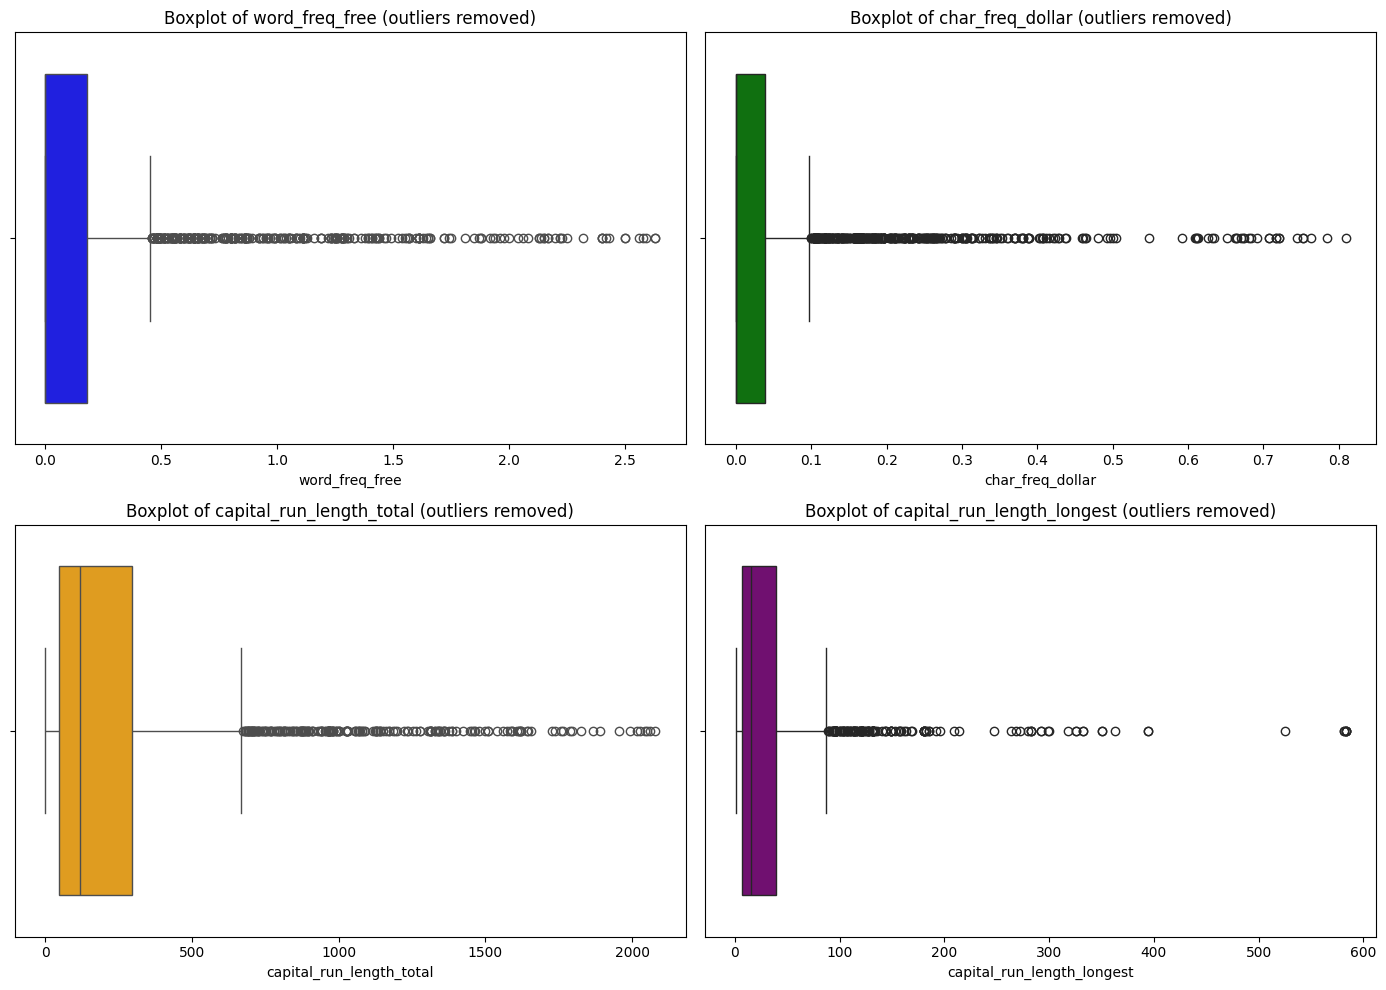

In [14]:
# Boxplots after outlier removal
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x=df_cleaned['word_freq_free'], color='blue')
plt.title('Boxplot of word_freq_free (outliers removed)')

plt.subplot(2, 2, 2)
sns.boxplot(x=df_cleaned['char_freq_dollar'], color='green')
plt.title('Boxplot of char_freq_dollar (outliers removed)')

plt.subplot(2, 2, 3)
sns.boxplot(x=df_cleaned['capital_run_length_total'], color='orange')
plt.title('Boxplot of capital_run_length_total (outliers removed)')

plt.subplot(2, 2, 4)
sns.boxplot(x=df_cleaned['capital_run_length_longest'], color='purple')
plt.title('Boxplot of capital_run_length_longest (outliers removed)')

plt.tight_layout()
plt.show()

## Building and Evaluating a Classification Model

Model Evaluation Metrics:
Training Accuracy: 0.9256
Testing Accuracy: 0.9039

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.91      0.95      0.92       273
        Spam       0.90      0.84      0.87       164

    accuracy                           0.90       437
   macro avg       0.90      0.89      0.90       437
weighted avg       0.90      0.90      0.90       437



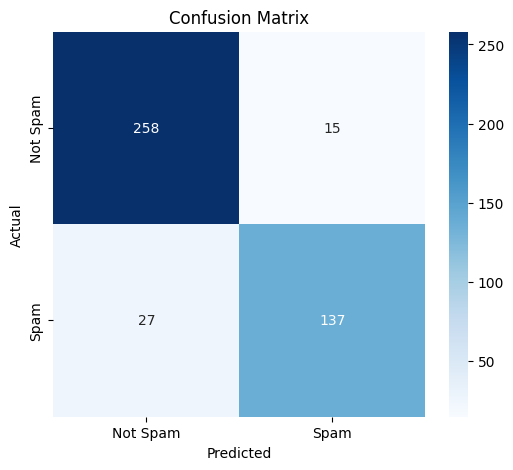

In [ ]:
# Step 1: Prepare data for classification
X = df_cleaned.drop('spam', axis=1)   # Features (all 57 columns except spam)
y = df_cleaned['spam']                 # Target (0 = not spam, 1 = spam)

# Step 2: Split into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Scale the features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Create and train the logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Step 5: Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Step 6: Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Model Evaluation Metrics:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Not Spam', 'Spam']))

# Step 7: Confusion matrix (visual)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Day 2: Comparing Classifiers

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df_cleaned.drop('spam', axis=1)
y = df_cleaned['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.svm import SVC

In [17]:
model = SVC()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [19]:
from sklearn.naive_bayes import GaussianNB

In [20]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)
y_pred_nb = model_nb.predict(X_test_scaled)

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_scaled, y_train)
y_pred_dt = model_dt.predict(X_test_scaled)

In [24]:
from sklearn.tree import plot_tree

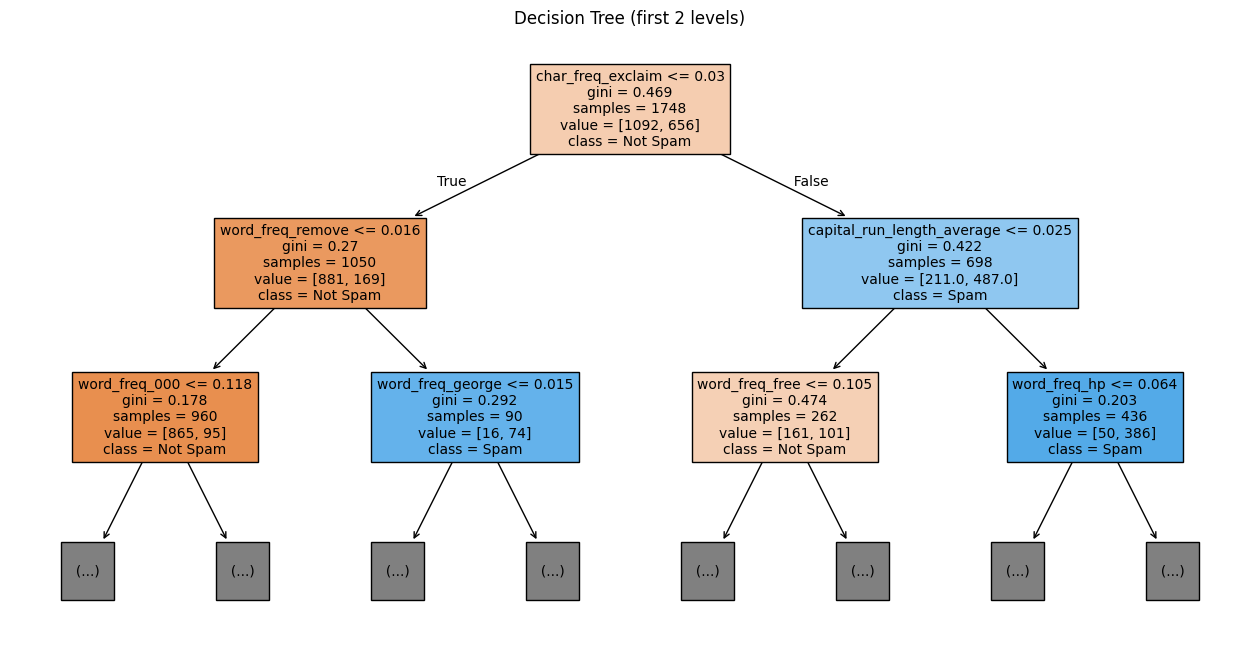

In [25]:
plt.figure(figsize=(16, 8))
plot_tree(model_dt, max_depth=2, feature_names=X.columns, class_names=['Not Spam', 'Spam'], filled=True, fontsize=10)
plt.title('Decision Tree (first 2 levels)')
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [28]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }

In [31]:
results = []
results.append(evaluate_model(y_test, y_pred, "SVM"))
results.append(evaluate_model(y_test, y_pred_nb, "Naive Bayes"))
results.append(evaluate_model(y_test, y_pred_dt, "Decision Tree"))

comparison_df = pd.DataFrame(results)
comparison_df

--- SVM ---
Accuracy:  0.9222
Precision: 0.9221
Recall:    0.8659
F1 Score:  0.8931

--- Naive Bayes ---
Accuracy:  0.7231
Precision: 0.5811
Recall:    0.9390
F1 Score:  0.7179

--- Decision Tree ---
Accuracy:  0.8902
Precision: 0.8494
Recall:    0.8598
F1 Score:  0.8545



,0
0,None
1,None
2,None


## Analysis of Results

SVM performed best overall, with the highest accuracy (0.922) and F1 score (0.893), suggesting it captured the relationships between features effectively without needing an independence assumption. Naive Bayes had the lowest accuracy (0.723) and F1 score (0.718), likely because its "naive" assumption that features are independent doesn't hold here — word and character frequencies in spam emails are often correlated (e.g., "free" and "$" tend to appear together), and treating them as unrelated hurts its ability to distinguish spam accurately. Interestingly, Naive Bayes had the *highest* recall (0.939) of all three models, meaning it caught almost all actual spam — but at the cost of the lowest precision (0.581), meaning it also misclassified many legitimate emails as spam. Decision Tree fell in between, performing reasonably well across all four metrics without the extreme precision/recall tradeoff seen in Naive Bayes.